In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
df = sns.load_dataset('titanic')
print("--- First 5 Rows ---")
print(df.head())
print("\n--- Dataset Info ---")
df.info()
print("\n--- Statistical Summary (for numerical columns) ---")
print(df.describe())
print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

--- First 5 Rows ---
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ----------

In [3]:
median_age = df['age'].median()
df['age'].fillna(median_age, inplace=True)
mode_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(mode_embarked, inplace=True)
df.drop('deck', axis=1, inplace=True)
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
df.drop(['alive', 'class', 'embark_town', 'who', 'adult_male'], axis=1, inplace=True)
print("--- Cleaned Data Info ---")
df.info()
print("\n--- First 5 Rows of Cleaned Data ---")
print(df.head())

--- Cleaned Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   age         891 non-null    float64
 3   sibsp       891 non-null    int64  
 4   parch       891 non-null    int64  
 5   fare        891 non-null    float64
 6   alone       891 non-null    bool   
 7   sex_male    891 non-null    bool   
 8   embarked_Q  891 non-null    bool   
 9   embarked_S  891 non-null    bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 45.4 KB

--- First 5 Rows of Cleaned Data ---
   survived  pclass   age  sibsp  parch     fare  alone  sex_male  embarked_Q  \
0         0       3  22.0      1      0   7.2500  False      True       False   
1         1       1  38.0      1      0  71.2833  False     False       False   
2         1       3  26.0      0    

/tmp/ipykernel_119443/3130499848.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(median_age, inplace=True)
/tmp/ipykernel_119443/3130499848.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

X = df.drop('survived', axis=1)
y = df['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
print("Logistic Regression model trained successfully!")
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)
print("Decision Tree model trained successfully!")
rand_forest = RandomForestClassifier(random_state=42)
rand_forest.fit(X_train, y_train)
print("Random Forest model trained successfully!")
svm = SVC()
svm.fit(X_train, y_train)
print("SVM model trained successfully!")

Logistic Regression model trained successfully!
Decision Tree model trained successfully!
Random Forest model trained successfully!
SVM model trained successfully!


In [ ]:

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dec_tree,
    "Random Forest": rand_forest,
    "Support Vector Machine": svm
}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print("\n" + "="*30 + "\n")

--- Logistic Regression Performance ---
Accuracy: 0.7989
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



--- Decision Tree Performance ---
Accuracy: 0.7877
              precision    recall  f1-score   support

           0       0.83      0.80      0.82       105
           1       0.73      0.77      0.75        74

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.79      0.79      0.79       179



--- Random Forest Performance ---
Accuracy: 0.8156
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy       

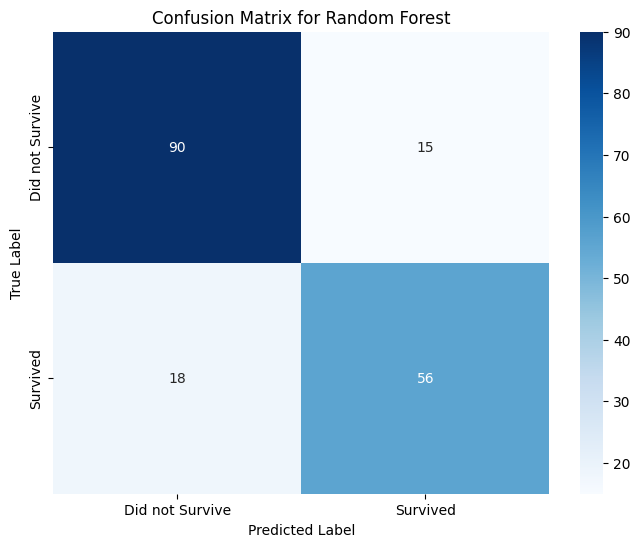

In [ ]:

y_pred_rf = rand_forest.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Did not Survive', 'Survived'], 
            yticklabels=['Did not Survive', 'Survived'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [ ]:

new_passenger_data = {
    'pclass': [1, 3],
    'age': [19.0, 28.0], 
    'sibsp': [1, 0],
    'parch': [0, 0],
    'fare': [90.0, 7.0],
    'sex_male': [0, 1], 
    'embarked_Q': [0, 0],
    'embarked_S': [0, 1]  
}
new_passengers = pd.DataFrame(new_passenger_data)
new_passengers['alone'] = ((new_passengers['sibsp'] == 0) & (new_passengers['parch'] == 0)).astype(int)
expected_columns = X_train.columns
new_passengers = new_passengers[expected_columns]

predictions = rand_forest.predict(new_passengers)
probabilities = rand_forest.predict_proba(new_passengers)
for i, prediction in enumerate(predictions):
    survival_prob = probabilities[i][1]
    if prediction == 1:
        print(f"Passenger {i+1} is predicted to: SURVIVE (Confidence: {survival_prob:.2%})")
    else:
        print(f"Passenger {i+1} is predicted to: NOT SURVIVE (Confidence: {1-survival_prob:.2%})")

Passenger 1 is predicted to: SURVIVE (Confidence: 100.00%)
Passenger 2 is predicted to: NOT SURVIVE (Confidence: 68.00%)


In [ ]:
print("--- Model's Expected Columns (X_train) ---")
print(X_train.columns.tolist())
print(f"Total columns: {len(X_train.columns)}")

print("\n--- Your New Data's Columns (new_passengers) ---")
print(new_passengers.columns.tolist())
print(f"Total columns: {len(new_passengers.columns)}")

--- Model's Expected Columns (X_train) ---
['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone', 'sex_male', 'embarked_Q', 'embarked_S']
Total columns: 9

--- Your New Data's Columns (new_passengers) ---
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'alone']
Total columns: 9
